# Notebook 1: Xử lý Dữ liệu & EDA với Apache Spark

**Môn học:** Cơ sở Dữ liệu Phân tán

**Dataset:** Hunter Supermarket — 2,019,501 bản ghi, 12 biến

**Mục tiêu notebook này:**
1. Khởi tạo SparkSession (phân tán)
2. Load dữ liệu lên Spark DataFrame
3. Tiền xử lý dữ liệu (missing values, outliers, feature engineering)
4. Phân tích EDA phân tán (shopping patterns, product stats)
5. Thuật toán FP-Growth (khai thác luật kết hợp)
6. Lưu kết quả dạng Parquet để Notebook 2 sử dụng

## 1. Cài đặt & Import thư viện

> **Quan trọng:** `HADOOP_HOME` phải được set **TRƯỚC** khi import PySpark để JVM nhận đúng đường dẫn winutils.exe.

In [ ]:
import os, warnings, sys
warnings.filterwarnings('ignore')

HADOOP_HOME = os.path.join(os.getcwd(), 'hadoop')
os.environ['HADOOP_HOME'] = HADOOP_HOME
os.environ['PATH'] = os.path.join(HADOOP_HOME, 'bin') + ';' + os.environ.get('PATH', '')
print(f'✓ HADOOP_HOME = {HADOOP_HOME}')
print(f'✓ winutils.exe exists: {os.path.exists(os.path.join(HADOOP_HOME, "bin", "winutils.exe"))}')

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib; matplotlib.rcParams['figure.dpi'] = 100
import seaborn as sns
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import *
from pyspark.sql.window import Window
from pyspark.ml.fpm import FPGrowth
print('✓ Import thành công!')

✓ HADOOP_HOME = c:\Distributed Data\hadoop
✓ winutils.exe exists: True
✓ Import thành công!


## 2. Khởi tạo SparkSession (Phân tán)

> **Kiến trúc phân tán:** SparkSession là entry point cho Spark. Trong môi trường cluster, master có thể là `yarn`, `mesos`, hoặc địa chỉ Spark Standalone cluster (ví dụ `spark://master:7077`). Ở đây ta dùng `local[*]` để mô phỏng trên máy cục bộ với tất cả CPU cores.

In [2]:
spark = SparkSession.builder \
    .appName('SupermarketAnalytics_DataProcessing') \
    .master('local[*]') \
    .config('spark.executor.memory', '4g') \
    .config('spark.driver.memory', '4g') \
    .config('spark.sql.shuffle.partitions', '8') \
    .config('spark.default.parallelism', '8') \
    .getOrCreate()
spark.sparkContext.setLogLevel('WARN')
print(f'Spark version: {spark.version}')
print(f'Master: {spark.sparkContext.master}')
print(f'App Name: {spark.sparkContext.appName}')
print(f'Default Parallelism: {spark.sparkContext.defaultParallelism}')
print(f'Spark UI: {spark.sparkContext.uiWebUrl}')

Spark version: 4.1.1
Master: local[*]
App Name: SupermarketAnalytics_DataProcessing
Default Parallelism: 8
Spark UI: http://host.docker.internal:4040


## 3. Load Dữ liệu vào Spark DataFrame

> **Spark DataFrame** khác Pandas DataFrame ở chỗ dữ liệu được phân tán trên nhiều node (workers). Các phép tính được thực hiện song song trên từng partition.

In [3]:
DATA_PATH = 'ECommerce_consumer behaviour.csv'
schema = StructType([
    StructField('order_id', LongType(), True),
    StructField('user_id', LongType(), True),
    StructField('order_number', IntegerType(), True),
    StructField('order_dow', IntegerType(), True),
    StructField('order_hour_of_day', IntegerType(), True),
    StructField('days_since_prior_order', DoubleType(), True),
    StructField('product_id', LongType(), True),
    StructField('add_to_cart_order', IntegerType(), True),
    StructField('reordered', IntegerType(), True),
    StructField('department_id', IntegerType(), True),
    StructField('department', StringType(), True),
    StructField('product_name', StringType(), True)
])
df = spark.read.csv(DATA_PATH, header=True, schema=schema)
df = df.repartition(8)
print(f'Dataset shape: {df.count():,} rows x {len(df.columns)} columns')
print(f'Số partitions: {df.rdd.getNumPartitions()}')
print(f'\nColumns: {df.columns}')
df.printSchema()

Dataset shape: 2,019,501 rows x 12 columns
Số partitions: 8

Columns: ['order_id', 'user_id', 'order_number', 'order_dow', 'order_hour_of_day', 'days_since_prior_order', 'product_id', 'add_to_cart_order', 'reordered', 'department_id', 'department', 'product_name']
root
 |-- order_id: long (nullable = true)
 |-- user_id: long (nullable = true)
 |-- order_number: integer (nullable = true)
 |-- order_dow: integer (nullable = true)
 |-- order_hour_of_day: integer (nullable = true)
 |-- days_since_prior_order: double (nullable = true)
 |-- product_id: long (nullable = true)
 |-- add_to_cart_order: integer (nullable = true)
 |-- reordered: integer (nullable = true)
 |-- department_id: integer (nullable = true)
 |-- department: string (nullable = true)
 |-- product_name: string (nullable = true)



In [4]:
df.show(10, truncate=False)

+--------+-------+------------+---------+-----------------+----------------------+----------+-----------------+---------+-------------+------------+-------------------+
|order_id|user_id|order_number|order_dow|order_hour_of_day|days_since_prior_order|product_id|add_to_cart_order|reordered|department_id|department  |product_name       |
+--------+-------+------------+---------+-----------------+----------------------+----------+-----------------+---------+-------------+------------+-------------------+
|2197793 |9855   |8           |6        |11               |21.0                  |13        |18               |0        |20           |deli        |prepared meals     |
|1899965 |151652 |87          |5        |15               |2.0                   |21        |4                |1        |16           |dairy eggs  |packaged cheese    |
|964116  |162524 |5           |1        |11               |10.0                  |31        |13               |0        |7            |beverages   |refrige

## 4. Tiền Xử Lý Dữ Liệu (Distributed)
### 4.1 Xử lý Missing Values

In [5]:
missing_counts = df.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in df.columns
]).collect()[0].asDict()
print('Missing values per column:')
for col, cnt in missing_counts.items():
    if cnt > 0:
        print(f'  {col}: {cnt:,}')
first_orders_null = df.filter(
    F.col('days_since_prior_order').isNull()
).select('order_number').distinct().collect()
print(f'\nOrder numbers với missing days_since_prior_order: {[r[0] for r in first_orders_null]}')
print('=> Đây là first-time orders (order_number = 1)')
df = df.fillna({'days_since_prior_order': -1})
print('\n✓ Đã fill missing values với -1 cho first-time purchases')

Missing values per column:
  days_since_prior_order: 124,342

Order numbers với missing days_since_prior_order: [1]
=> Đây là first-time orders (order_number = 1)

✓ Đã fill missing values với -1 cho first-time purchases


### 4.2 Phân tích Outliers

In [6]:
quantiles = df.approxQuantile('add_to_cart_order', [0.25, 0.75], 0.01)
Q1, Q3 = quantiles[0], quantiles[1]
IQR = Q3 - Q1
threshold = Q3 + 1.5 * IQR
max_val = df.agg(F.max('add_to_cart_order')).collect()[0][0]
outlier_count = df.filter(F.col('add_to_cart_order') > threshold).count()
print(f'Q1: {Q1}, Q3: {Q3}, IQR: {IQR}')
print(f'Threshold (Q3 + 1.5*IQR): {threshold}')
print(f'Max value: {max_val}')
print(f'Observations exceeding threshold: {outlier_count:,}')
print('=> Giữ lại outliers (wholesale/bulk purchases)')

Q1: 3.0, Q3: 12.0, IQR: 9.0
Threshold (Q3 + 1.5*IQR): 25.5
Max value: 137
Observations exceeding threshold: 62,029
=> Giữ lại outliers (wholesale/bulk purchases)


### 4.3 Feature Engineering

In [7]:
order_features = df.groupBy('order_id', 'user_id').agg(
    F.count('product_id').alias('total_items')
)
user_features = df.groupBy('user_id').agg(
    F.max('order_number').alias('total_orders'),
    F.mean(F.when(F.col('days_since_prior_order') >= 0, 
                  F.col('days_since_prior_order'))).alias('avg_days_between_orders'),
    F.count('product_id').alias('total_items_purchased'),
    F.mean('reordered').alias('avg_reorder_rate')
)
print(f'Order-level features: {order_features.count():,} orders')
print(f'User-level features: {user_features.count():,} users')
user_features.show(5)

Order-level features: 200,000 orders
User-level features: 105,273 users
+-------+------------+-----------------------+---------------------+-------------------+
|user_id|total_orders|avg_days_between_orders|total_items_purchased|   avg_reorder_rate|
+-------+------------+-----------------------+---------------------+-------------------+
| 196314|          91|                   1.82|                   50|                0.8|
| 134170|          11|                   11.0|                   13| 0.6153846153846154|
|  79314|          88|     3.3333333333333335|                   54| 0.8148148148148148|
|  68498|          20|      4.654545454545454|                   55|0.38181818181818183|
|  63014|          72|     2.5609756097560976|                   41| 0.5853658536585366|
+-------+------------+-----------------------+---------------------+-------------------+
only showing top 5 rows


## 5. EDA Phân tán
### 5.1 Shopping Day Preferences

Shopping Day Distribution:
  Monday: 17.5%
  Tuesday: 17.2%
  Wednesday: 13.6%
  Thursday: 12.8%
  Friday: 12.5%
  Saturday: 13.3%
  Sunday: 13.0%


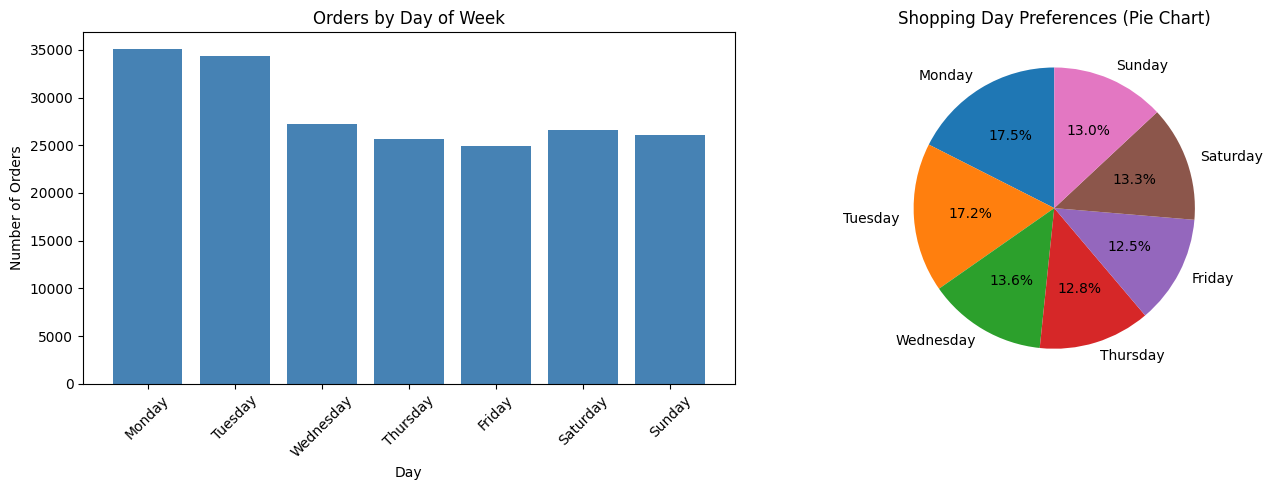

In [8]:
day_map = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 
           3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
orders_per_day = df.select('order_id', 'order_dow') \
    .distinct().groupBy('order_dow').count() \
    .orderBy('order_dow').toPandas()
orders_per_day['day_name'] = orders_per_day['order_dow'].map(day_map)
orders_per_day['percentage'] = orders_per_day['count'] / orders_per_day['count'].sum() * 100
print('Shopping Day Distribution:')
for _, row in orders_per_day.iterrows():
    print(f'  {row["day_name"]}: {row["percentage"]:.1f}%')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(orders_per_day['day_name'], orders_per_day['count'], color='steelblue')
axes[0].set_title('Orders by Day of Week')
axes[0].set_xlabel('Day'); axes[0].set_ylabel('Number of Orders')
axes[0].tick_params(axis='x', rotation=45)
axes[1].pie(orders_per_day['count'], labels=orders_per_day['day_name'],
           autopct='%1.1f%%', startangle=90)
axes[1].set_title('Shopping Day Preferences (Pie Chart)')
plt.tight_layout()
plt.savefig('eda_shopping_days.png', dpi=100, bbox_inches='tight')
plt.show()

### 5.2 Top Departments & Products

Top 10 Departments:
     department  count
        produce 588996
     dairy eggs 336915
         snacks 180692
      beverages 168126
         frozen 139536
         pantry 116262
         bakery  72983
   canned goods  66053
           deli  65176
dry goods pasta  54054


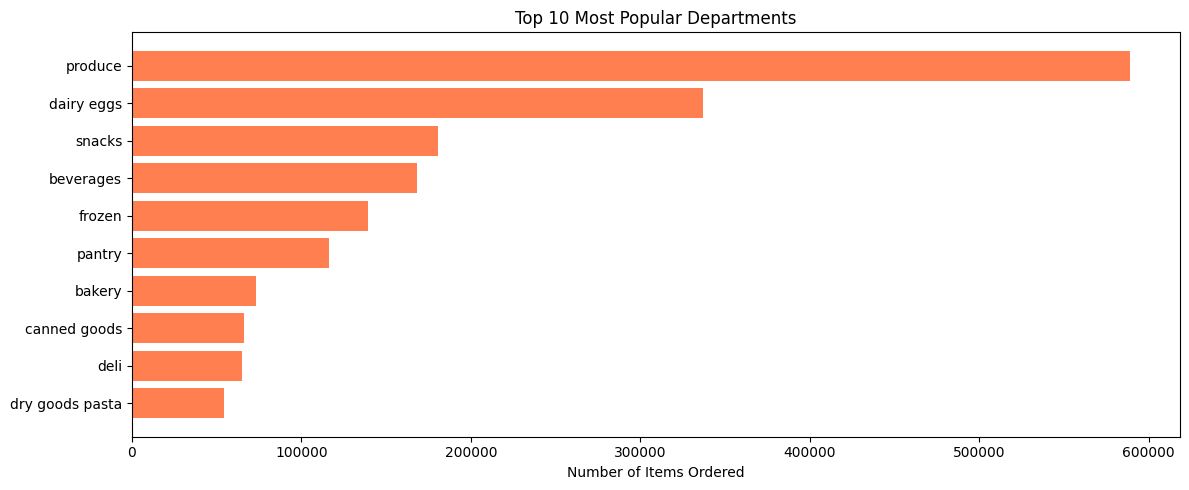

In [9]:
dept_counts = df.groupBy('department').count() \
    .orderBy(F.desc('count')).limit(10).toPandas()
print('Top 10 Departments:')
print(dept_counts.to_string(index=False))
plt.figure(figsize=(12, 5))
plt.barh(dept_counts['department'][::-1], dept_counts['count'][::-1], color='coral')
plt.title('Top 10 Most Popular Departments')
plt.xlabel('Number of Items Ordered')
plt.tight_layout()
plt.savefig('eda_top_departments.png', dpi=100, bbox_inches='tight')
plt.show()

Top 10 Products:
                 product_name  count
                 fresh fruits 226039
             fresh vegetables 212611
   packaged vegetables fruits 109596
                       yogurt  90751
              packaged cheese  61502
                         milk  55150
water seltzer sparkling water  52564
               chips pretzels  45306
              soy lactosefree  39389
                        bread  36381


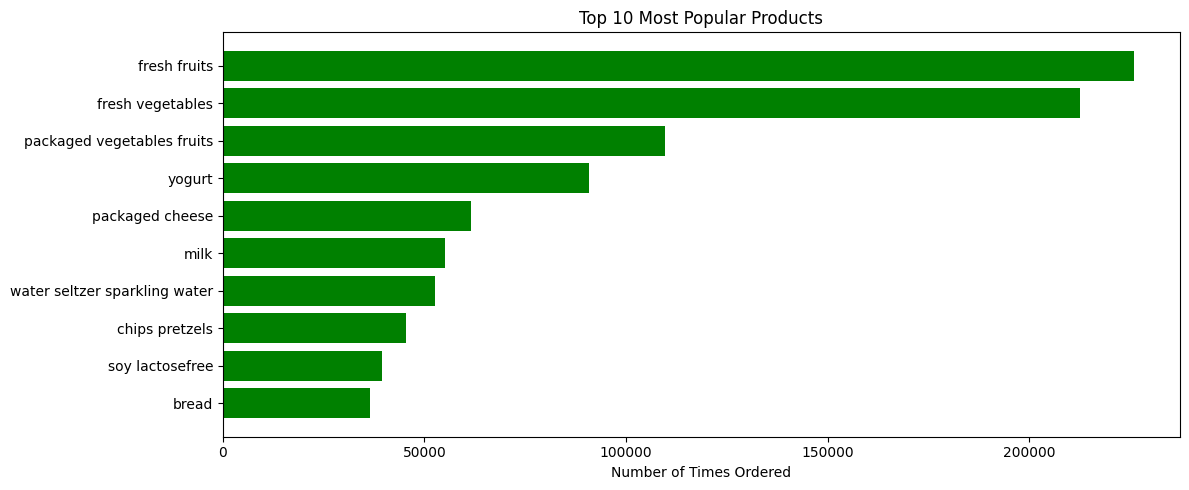

In [10]:
product_counts = df.groupBy('product_name').count() \
    .orderBy(F.desc('count')).limit(10).toPandas()
print('Top 10 Products:')
print(product_counts.to_string(index=False))
plt.figure(figsize=(12, 5))
plt.barh(product_counts['product_name'][::-1], product_counts['count'][::-1], color='green')
plt.title('Top 10 Most Popular Products')
plt.xlabel('Number of Times Ordered')
plt.tight_layout()
plt.savefig('eda_top_products.png', dpi=100, bbox_inches='tight')
plt.show()

### 5.3 Hour of Day Analysis

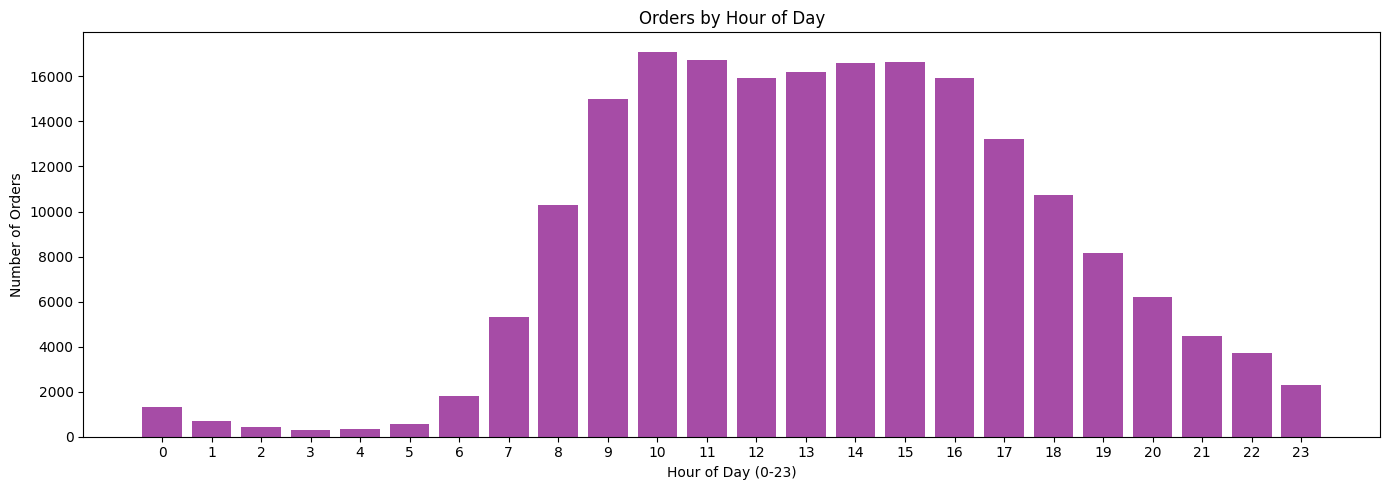

In [11]:
hour_counts = df.select('order_id', 'order_hour_of_day') \
    .distinct().groupBy('order_hour_of_day').count() \
    .orderBy('order_hour_of_day').toPandas()
plt.figure(figsize=(14, 5))
plt.bar(hour_counts['order_hour_of_day'], hour_counts['count'], color='purple', alpha=0.7)
plt.title('Orders by Hour of Day')
plt.xlabel('Hour of Day (0-23)'); plt.ylabel('Number of Orders')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.savefig('eda_hour_of_day.png', dpi=100, bbox_inches='tight')
plt.show()

### 5.4 Reorder Rate Analysis

Reorder Rate by Department:
     department  reorder_rate  total_orders
     dairy eggs      0.670193        336915
      beverages      0.654967        168126
        produce      0.649283        588996
         bakery      0.629859         72983
           deli      0.612449         65176
           pets      0.604357          6013
         babies      0.580918         25940
           bulk      0.576653          2133
         snacks      0.574370        180692
   meat seafood      0.572067         44271
      breakfast      0.561507         44605
        alcohol      0.557686          9439
         frozen      0.538463        139536
dry goods pasta      0.460317         54054
   canned goods      0.458178         66053
          other      0.404018          2240
      household      0.402144         46446
        missing      0.391661          4749
  international      0.360796         16738
         pantry      0.347947        116262
  personal care      0.326687         28134


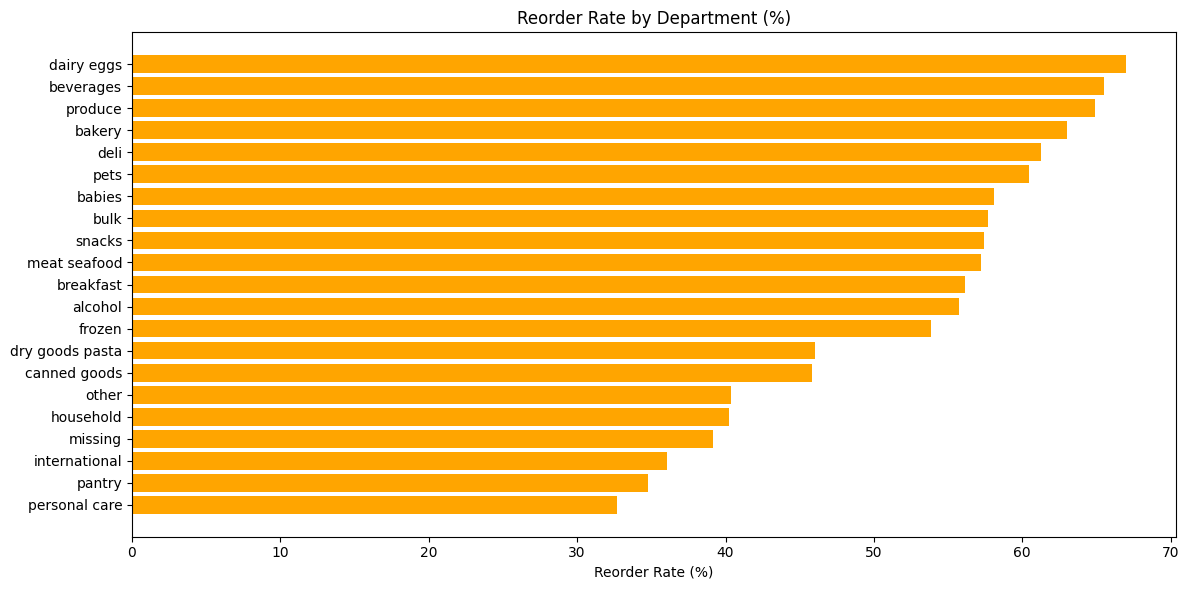

In [12]:
reorder_dept = df.groupBy('department').agg(
    F.mean('reordered').alias('reorder_rate'),
    F.count('product_id').alias('total_orders')
).orderBy(F.desc('reorder_rate')).toPandas()
print('Reorder Rate by Department:')
print(reorder_dept.to_string(index=False))
plt.figure(figsize=(12, 6))
plt.barh(reorder_dept['department'][::-1], 
         reorder_dept['reorder_rate'][::-1] * 100, color='orange')
plt.title('Reorder Rate by Department (%)')
plt.xlabel('Reorder Rate (%)')
plt.tight_layout()
plt.savefig('eda_reorder_rate.png', dpi=100, bbox_inches='tight')
plt.show()

## 6. Association Rule Mining với FP-Growth (Spark)

> **FP-Growth** là phiên bản Spark của thuật toán Apriori. Spark MLlib triển khai song song trên cluster.

**Phân tán:** Mỗi worker xây dựng FP-tree cục bộ, sau đó tổng hợp.

In [13]:
SAMPLE_FRAC = 0.05
basket_df = df.filter(F.col('product_name').isNotNull()) \
    .sample(fraction=SAMPLE_FRAC, seed=42) \
    .groupBy('order_id') \
    .agg(F.collect_set('product_name').alias('items'))
basket_df = basket_df.filter(F.size('items') >= 2)
print(f'Số orders trong sample: {basket_df.count():,}')
basket_df.show(5, truncate=70)

Số orders trong sample: 19,530
+--------+----------------------------------------------------+
|order_id|                                               items|
+--------+----------------------------------------------------+
|      28|                                    [cream, spreads]|
|     560|                      [frozen produce, fresh fruits]|
|    1359|[water seltzer sparkling water, ice cream ice, milk]|
|    1552|                   [packaged poultry, ice cream ice]|
|    3292|                            [fresh vegetables, milk]|
+--------+----------------------------------------------------+
only showing top 5 rows


In [14]:
fpGrowth = FPGrowth(
    itemsCol='items',
    minSupport=0.005,
    minConfidence=0.05,
    numPartitions=8
)
print('Đang chạy FP-Growth...')
model = fpGrowth.fit(basket_df)
print('✓ FP-Growth hoàn tất!')
freq_items = model.freqItemsets
print(f'Số frequent itemsets: {freq_items.count():,}')
freq_items.orderBy(F.desc('freq')).show(10, truncate=50)

Đang chạy FP-Growth...
✓ FP-Growth hoàn tất!
Số frequent itemsets: 114
+--------------------------------+----+
|                           items|freq|
+--------------------------------+----+
|                  [fresh fruits]|4479|
|              [fresh vegetables]|4415|
|    [packaged vegetables fruits]|2426|
|                        [yogurt]|1963|
|               [packaged cheese]|1535|
|                          [milk]|1275|
| [water seltzer sparkling water]|1017|
|                [chips pretzels]|1007|
|[fresh vegetables, fresh fruits]| 877|
|               [soy lactosefree]| 873|
+--------------------------------+----+
only showing top 10 rows


In [15]:
assoc_rules = model.associationRules
print(f'Số association rules: {assoc_rules.count():,}')
assoc_rules.orderBy(F.desc('confidence')).show(10, truncate=50)
rules_pd = assoc_rules.orderBy(F.desc('lift')).limit(20).toPandas()
print('\nTop 10 rules by LIFT:')
print(rules_pd[['antecedent', 'consequent', 'support', 'confidence', 'lift']].head(10).to_string(index=False))

Số association rules: 43
+----------------------------+------------------+-------------------+------------------+--------------------+
|                  antecedent|        consequent|         confidence|              lift|             support|
+----------------------------+------------------+-------------------+------------------+--------------------+
|               [fresh herbs]|[fresh vegetables]|0.29704797047970477|1.3140083495965196|0.008243727598566309|
|        [canned meals beans]|[fresh vegetables]| 0.2336448598130841|1.0335411352547073|0.005120327700972862|
|  [canned jarred vegetables]|[fresh vegetables]|0.22012578616352202|0.9737387551016047|0.005376344086021506|
|[packaged vegetables fruits]|[fresh vegetables]|0.20280296784830998|0.8971102971862953|0.025192012288786484|
|          [fresh vegetables]|    [fresh fruits]|0.19864099660249152|0.8661439302627058|   0.044905273937532|
|       [soup broth bouillon]|[fresh vegetables]|0.19765166340508805|0.8743232132052932|0.00517

## 7. Lưu Kết quả dạng Parquet (Hadoop)

> **Parquet** là columnar storage format chuẩn trong hệ sinh thái Hadoop/Spark. Ưu điểm:
> - Nén dữ liệu hiệu quả (snappy/gzip)
> - Đọc nhanh hơn CSV nhờ column pruning
> - Giữ nguyên schema (data types)

In [16]:
OUTPUT_DIR = 'spark_output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Lưu Parquet (Hadoop columnar format)
print('Đang lưu cleaned_data.parquet...')
df.write.mode('overwrite').parquet(f'{OUTPUT_DIR}/cleaned_data.parquet')
print('Đang lưu user_features.parquet...')
user_features.write.mode('overwrite').parquet(f'{OUTPUT_DIR}/user_features.parquet')
print('Đang lưu order_features.parquet...')
order_features.write.mode('overwrite').parquet(f'{OUTPUT_DIR}/order_features.parquet')

print(f'\n✓ Đã lưu dữ liệu Parquet vào: {OUTPUT_DIR}/')
print(f'  - cleaned_data.parquet')
print(f'  - user_features.parquet')
print(f'  - order_features.parquet')
print(f'\nNotebook 2 sẽ load Parquet từ thư mục này để training!')

Đang lưu cleaned_data.parquet...
Đang lưu user_features.parquet...
Đang lưu order_features.parquet...

✓ Đã lưu dữ liệu Parquet vào: spark_output/
  - cleaned_data.parquet
  - user_features.parquet
  - order_features.parquet

Notebook 2 sẽ load Parquet từ thư mục này để training!


## 8. Tổng kết Notebook 1

| Bước | Kỹ thuật Spark | Kết quả |
|------|---------------|--------|
| Load Data | `SparkSession.read.csv()` với schema | 2M+ records phân tán |
| Missing Values | `fillna()` song song | NaN → -1 |
| Outliers | `approxQuantile()` | Giữ lại |
| Feature Eng | `groupBy().agg()` | Order + User features |
| EDA | `groupBy().count()` | Shopping patterns |
| FP-Growth | `FPGrowth` (Spark MLlib) | Association rules |
| Lưu | `.write.parquet()` (Hadoop) | Parquet files |

**→ Notebook 2: Training phân tán (Recommender, Clustering, Forecasting)**

In [17]:
spark.stop()
print('SparkSession đã dừng. Chạy Notebook 2 để training!')

SparkSession đã dừng. Chạy Notebook 2 để training!
